In [ ]:
# NAV Trend Analysis (2022–2026

This analysis visualizes daily NAV movement across all mutual fund schemes and identifies major market trends.

In [1]:
import pandas as pd

nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")

nav["date"] = pd.to_datetime(nav["date"])

print(nav.shape)
nav.head()

(46000, 3)


,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


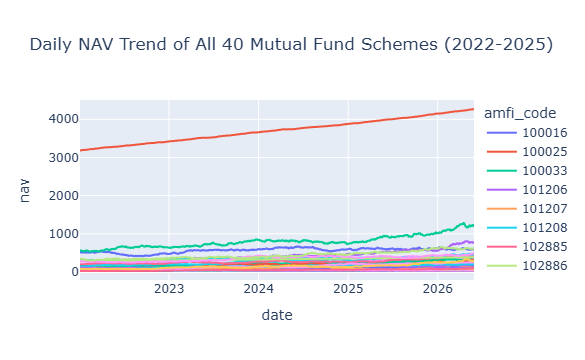

In [2]:
import plotly.express as px

fig = px.line(
    nav,
    x="date",
    y="nav",
    color="amfi_code",
    title="Daily NAV Trend of All 40 Mutual Fund Schemes (2022-2025)"
)

fig.show()

In [3]:
fig.write_image("charts/nav_trend_all_funds.png")

In [4]:
sip = pd.read_csv("data/processed/04_monthly_sip_inflows_cleaned.csv")

In [5]:
sip.head()

,month,sip_inflow_crore,active_sip_accounts_crore,new_sip_accounts_lakh,sip_aum_lakh_crore,yoy_growth_pct
0,2022-01,11517,4.91,9.10,4.80,NaN
1,2022-02,11438,4.93,8.20,4.85,NaN
2,2022-03,12328,5.09,10.50,5.01,NaN
3,2022-04,11863,5.48,9.52,5.12,NaN
4,2022-05,12286,5.55,8.10,5.15,NaN


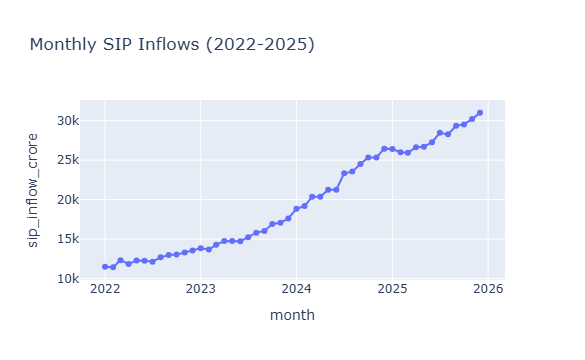

In [6]:
import plotly.express as px

fig = px.line(
    sip,
    x="month",
    y="sip_inflow_crore",
    markers=True,
    title="Monthly SIP Inflows (2022-2025)"
)

fig.show()

In [7]:
fig.write_image("charts/sip_inflow_trend.png")

In [8]:
aum = pd.read_csv("data/processed/03_aum_by_fund_house_cleaned.csv")

In [9]:
aum["year"] = pd.to_datetime(aum["date"]).dt.year

In [10]:
aum.head()

,date,fund_house,aum_lakh_crore,aum_crore,num_schemes,year
0,2022-03-31,SBI Mutual Fund,6.05,605000,186,2022
1,2022-03-31,ICICI Prudential MF,4.65,465000,216,2022
2,2022-03-31,HDFC Mutual Fund,4.35,435000,195,2022
3,2022-03-31,Nippon India MF,2.70,270000,177,2022
4,2022-03-31,Kotak Mahindra MF,2.70,270000,168,2022


In [12]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries loaded successfully!")

Libraries loaded successfully!


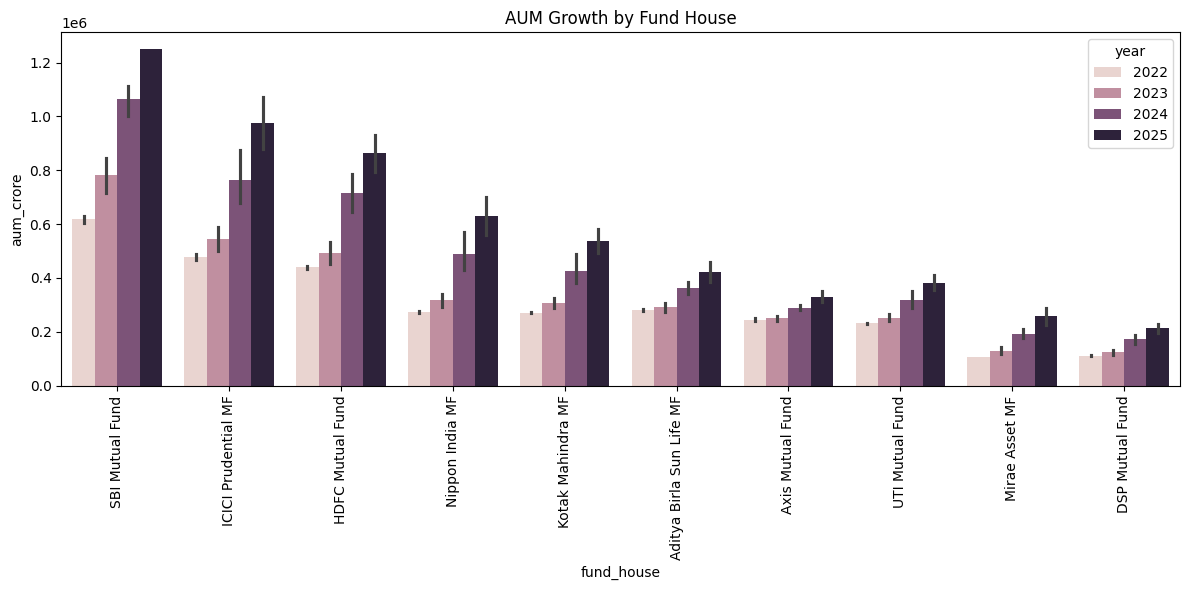

In [13]:
plt.figure(figsize=(12,6))

sns.barplot(
    data=aum,
    x="fund_house",
    y="aum_crore",
    hue="year"
)

plt.xticks(rotation=90)
plt.title("AUM Growth by Fund House")
plt.tight_layout()

plt.savefig("charts/aum_growth.png")
plt.show()

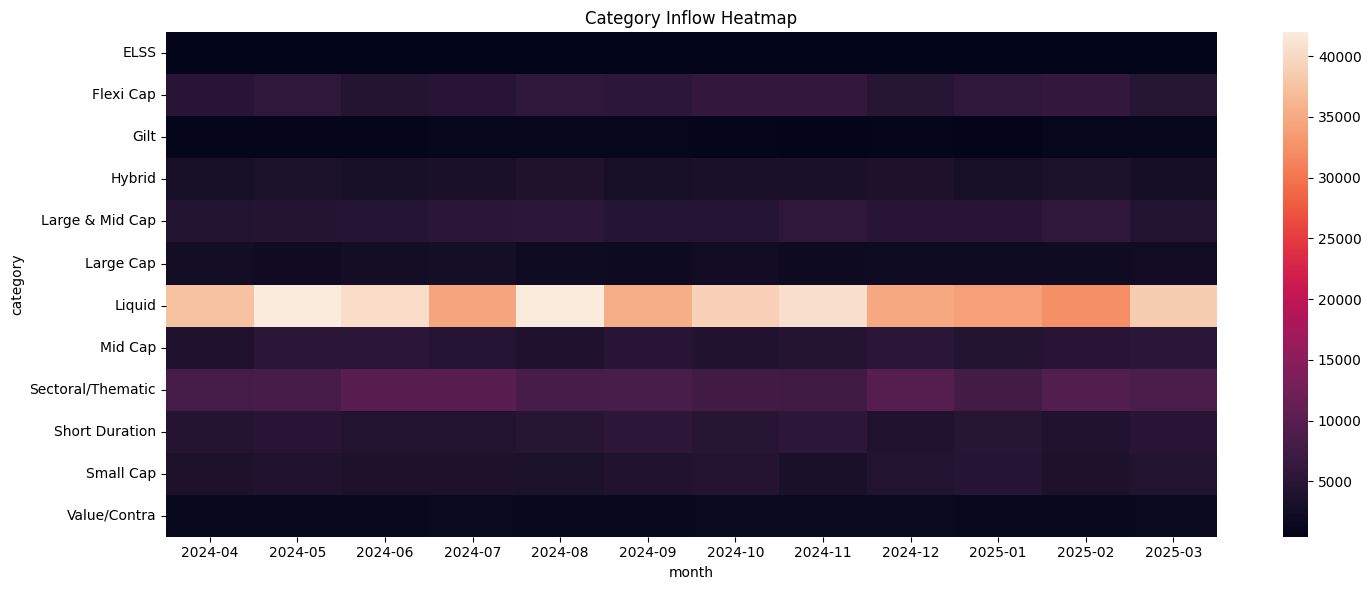

In [14]:
category = pd.read_csv(
    "data/processed/05_category_inflows_cleaned.csv"
)

pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,6))

sns.heatmap(pivot)

plt.title("Category Inflow Heatmap")
plt.tight_layout()

plt.savefig("charts/category_heatmap.png")
plt.show()

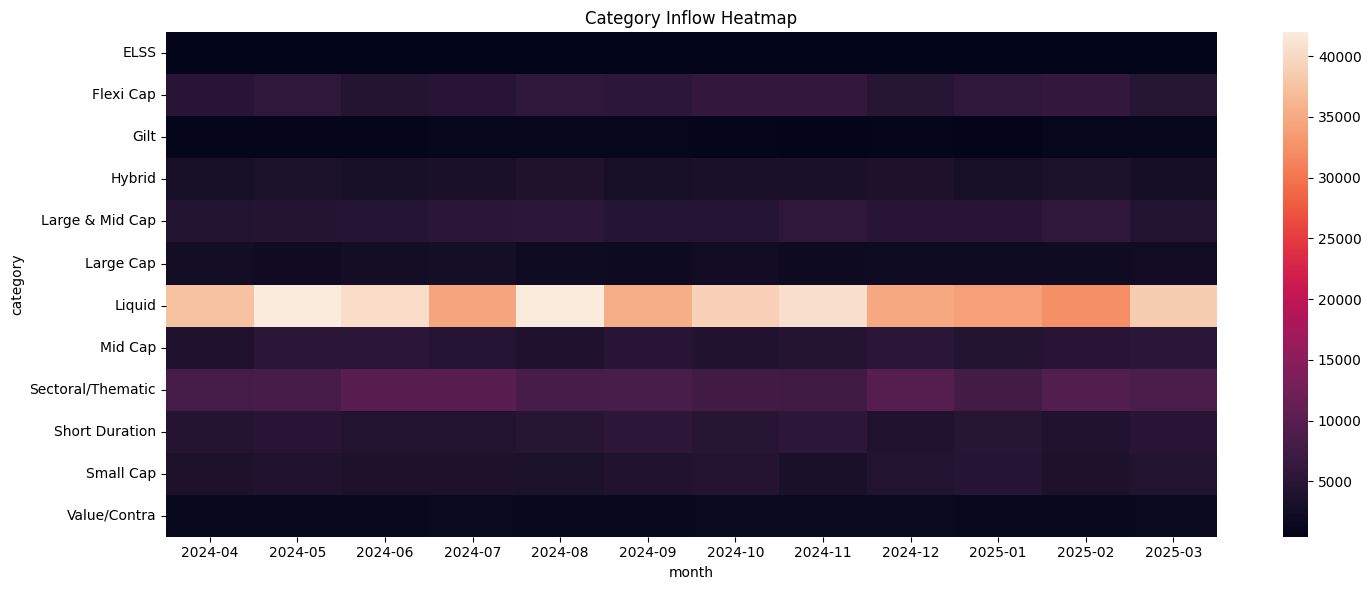

In [15]:
category = pd.read_csv(
    "data/processed/05_category_inflows_cleaned.csv"
)

pivot = category.pivot(
    index="category",
    columns="month",
    values="net_inflow_crore"
)

plt.figure(figsize=(15,6))

sns.heatmap(pivot)

plt.title("Category Inflow Heatmap")
plt.tight_layout()

plt.savefig("charts/category_heatmap.png")
plt.show()

In [17]:
import pandas as pd

txn = pd.read_csv(
    "data/processed/08_investor_transactions_cleaned.csv"
)

print(txn.shape)
txn.head()

(32778, 13)


,investor_id,transaction_date,amfi_code,transaction_type,amount_inr,state,city,city_tier,age_group,gender,annual_income_lakh,payment_mode,kyc_status
0,INV003054,2024-01-01,119092,SIP,1834,Telangana,Hyderabad,T30,56+,Female,77.1,UPI,Verified
1,INV002952,2024-01-01,148567,REDEMPTION,392882,Punjab,Amritsar,B30,18-25,Male,7.1,Cheque,Verified
2,INV003420,2024-01-01,118636,SIP,912,Haryana,Faridabad,B30,36-45,Male,47.2,Mandate,Verified
3,INV003436,2024-01-01,118634,SIP,1102,Maharashtra,Mumbai,T30,36-45,Female,54.4,Cheque,Pending
4,INV004691,2024-01-01,119094,LUMPSUM,8682,Delhi,Noida,T30,26-35,Male,14.5,Net Banking,Pending


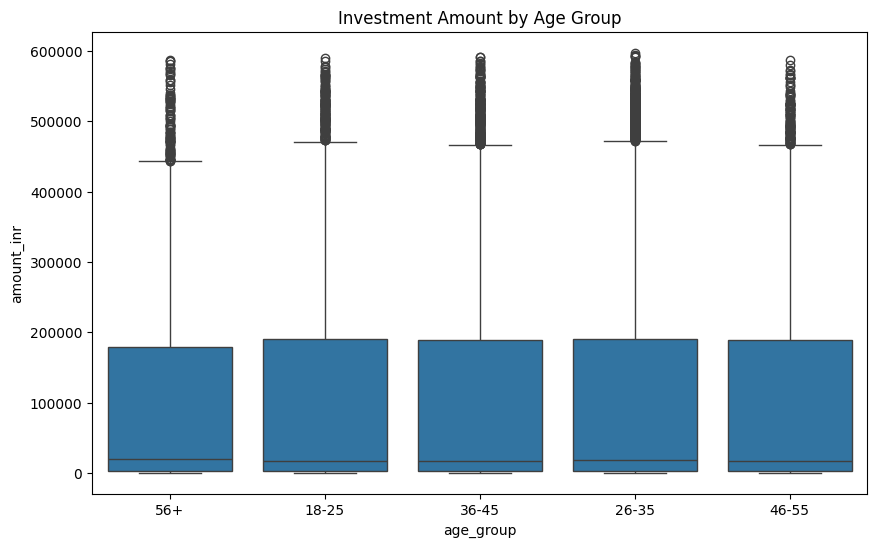

In [18]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.savefig("charts/age_group_boxplot.png")
plt.show()

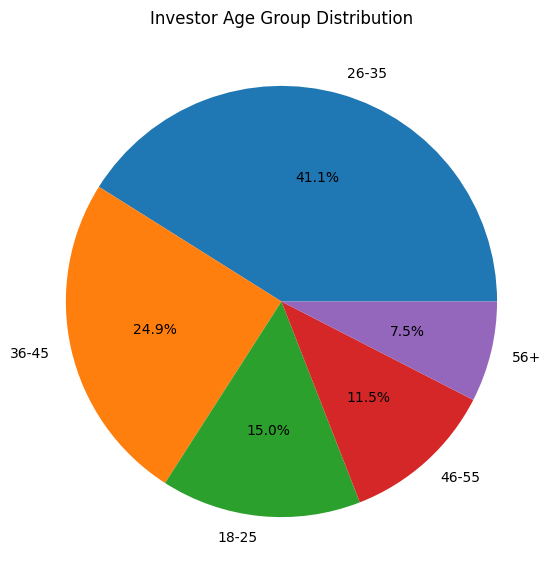

In [19]:
txn = pd.read_csv(
    "data/processed/08_investor_transactions_cleaned.csv"
)

age_counts = txn["age_group"].value_counts()

plt.figure(figsize=(7,7))
plt.pie(age_counts, labels=age_counts.index, autopct="%1.1f%%")
plt.title("Investor Age Group Distribution")

plt.savefig("charts/age_group_distribution.png")
plt.show()

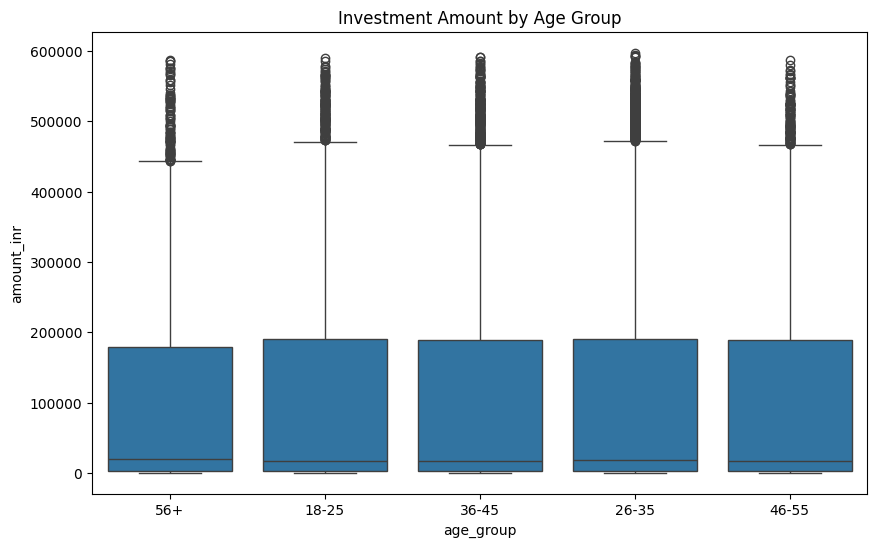

In [20]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")

plt.savefig("charts/age_group_boxplot.png")
plt.show()

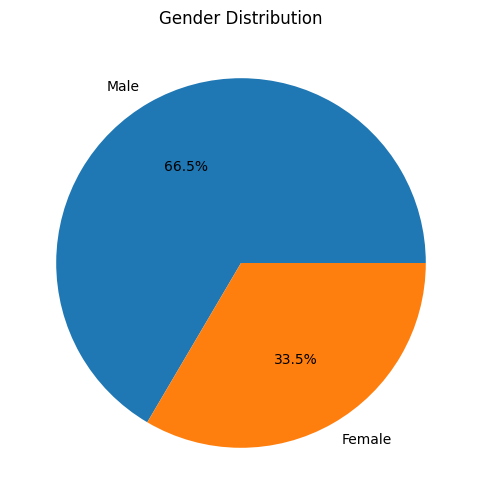

In [21]:
gender = txn["gender"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender,
    labels=gender.index,
    autopct="%1.1f%%"
)

plt.title("Gender Distribution")

plt.savefig("charts/gender_distribution.png")
plt.show()

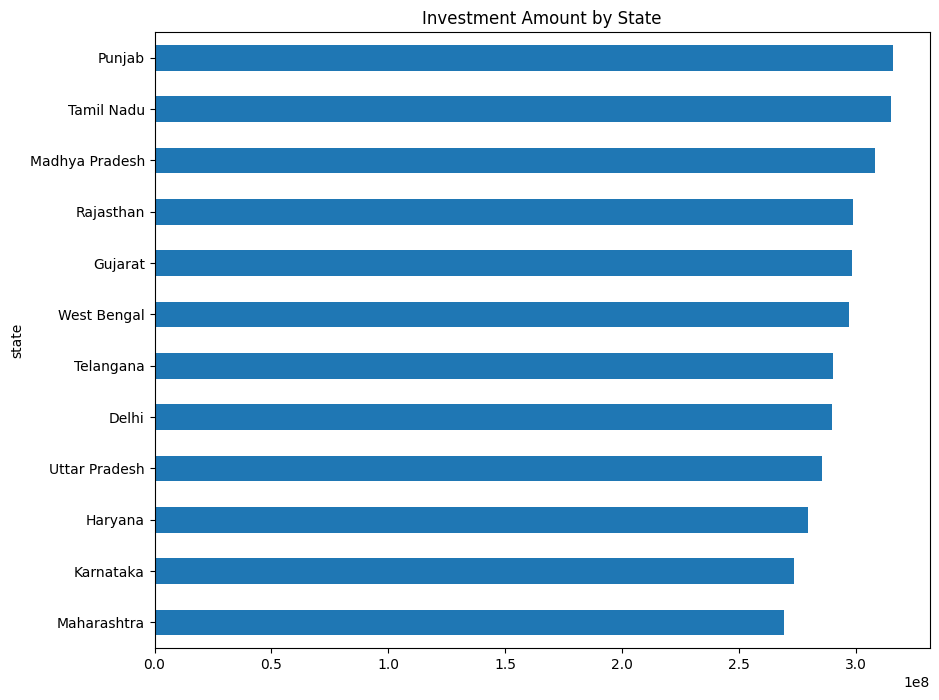

In [22]:
state_amt = txn.groupby("state")["amount_inr"].sum()

state_amt = state_amt.sort_values()

plt.figure(figsize=(10,8))

state_amt.plot(kind="barh")

plt.title("Investment Amount by State")

plt.savefig("charts/state_distribution.png")
plt.show()

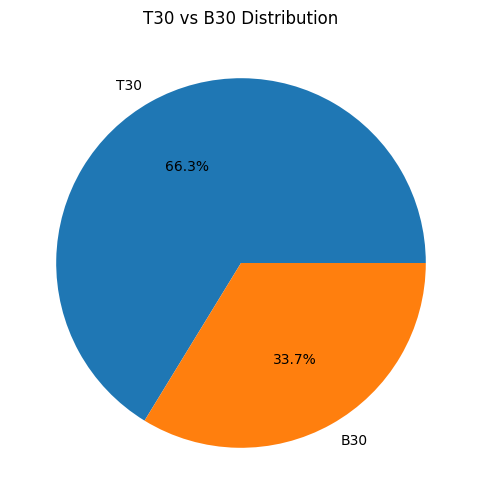

In [23]:
tier = txn["city_tier"].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    tier,
    labels=tier.index,
    autopct="%1.1f%%"
)

plt.title("T30 vs B30 Distribution")

plt.savefig("charts/city_tier_distribution.png")
plt.show()

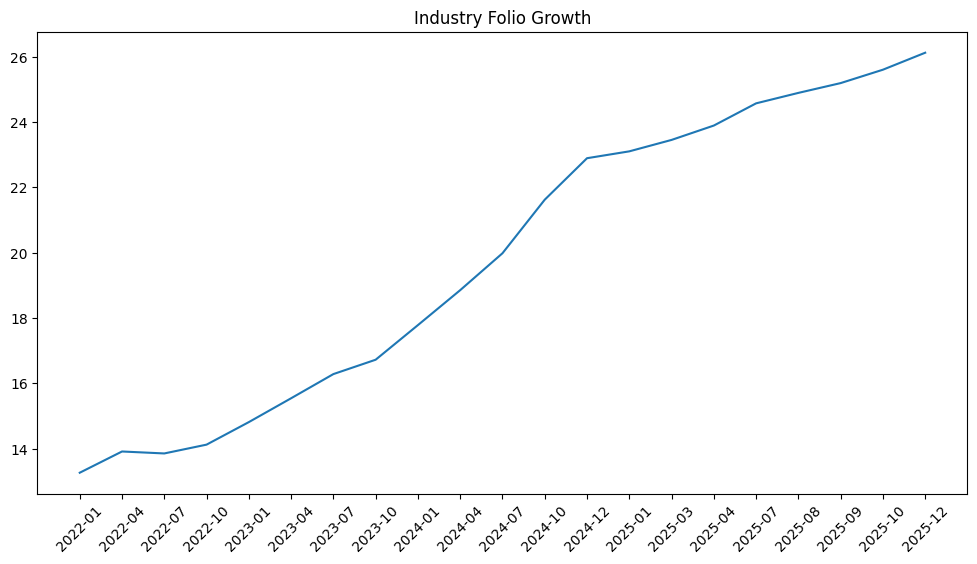

In [24]:
folio = pd.read_csv(
    "data/processed/06_industry_folio_count_cleaned.csv"
)

plt.figure(figsize=(12,6))

plt.plot(
    folio["month"],
    folio["total_folios_crore"]
)

plt.xticks(rotation=45)

plt.title("Industry Folio Growth")

plt.savefig("charts/folio_growth.png")
plt.show()

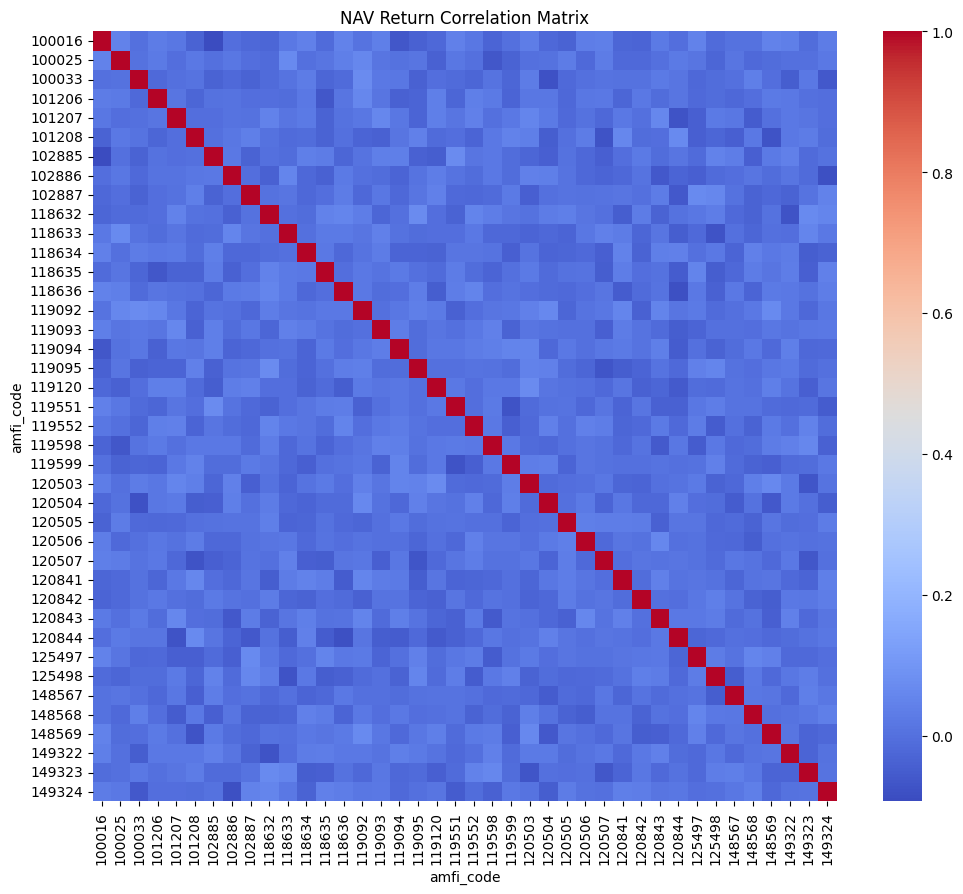

In [25]:
pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.title("NAV Return Correlation Matrix")

plt.savefig("charts/correlation_matrix.png")
plt.show()

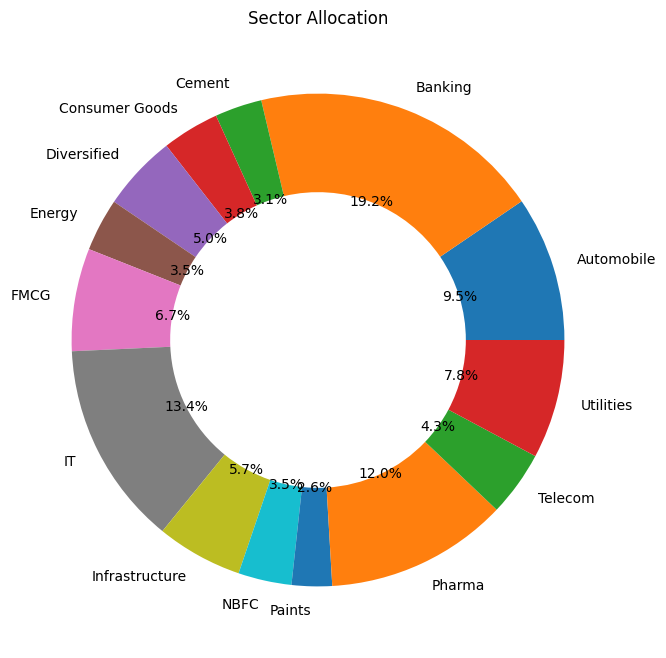

In [26]:
portfolio = pd.read_csv(
    "data/processed/09_portfolio_holdings_cleaned.csv"
)

sector = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))

plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation")

plt.savefig("charts/sector_allocation.png")
plt.show()

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [3]:
txn = pd.read_csv(
    "data/processed/08_investor_transactions_cleaned.csv"
)

print(txn.shape)

(32778, 13)


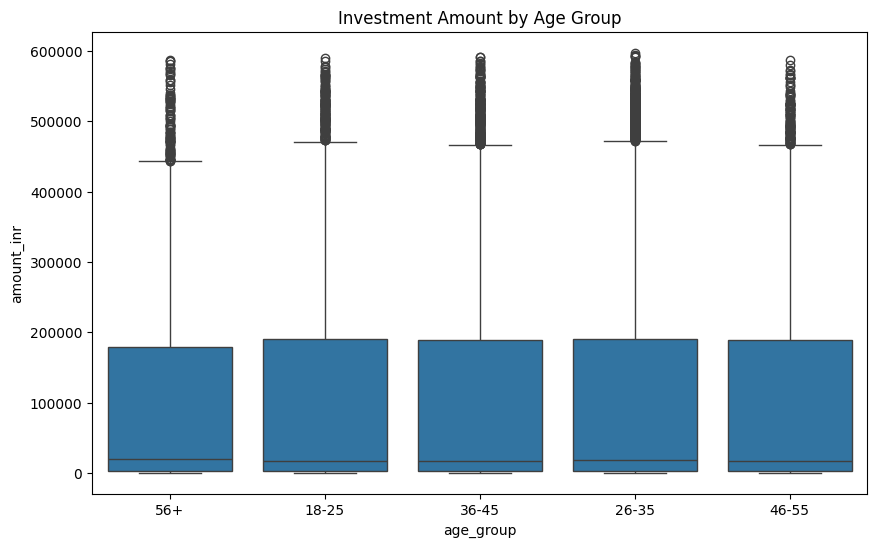

In [4]:
plt.figure(figsize=(10,6))

sns.boxplot(
    data=txn,
    x="age_group",
    y="amount_inr"
)

plt.title("Investment Amount by Age Group")
plt.show()

In [3]:
import pandas as pd

nav = pd.read_csv(
    "data/processed/02_nav_history_cleaned.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

print(nav.shape)

(46000, 3)


In [7]:
txn = pd.read_csv(
    "data/processed/08_investor_transactions_cleaned.csv"
)

print(txn.shape)

(32778, 13)


In [9]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

print("Libraries loaded successfully!")

Libraries loaded successfully!


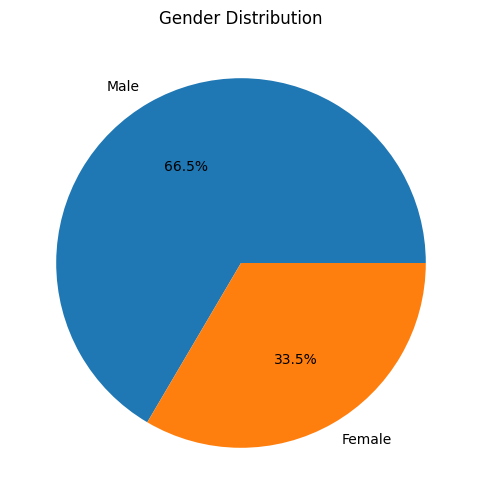

In [11]:
gender = txn["gender"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(gender, labels=gender.index, autopct="%1.1f%%")
plt.title("Gender Distribution")
plt.savefig("charts/gender_distribution.png")
plt.show()

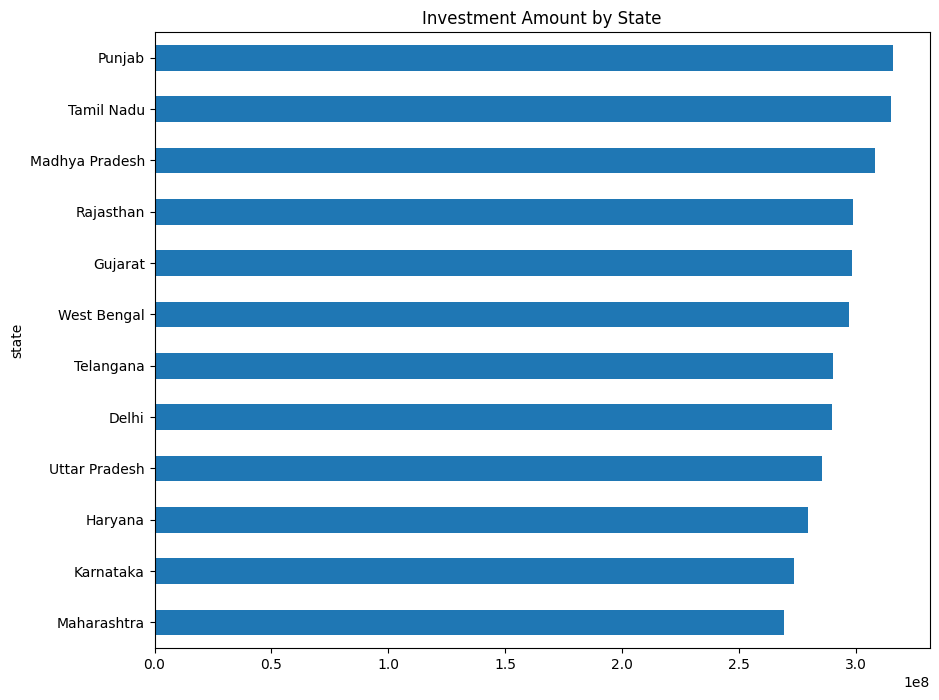

In [12]:
state_amt = txn.groupby("state")["amount_inr"].sum().sort_values()

plt.figure(figsize=(10,8))
state_amt.plot(kind="barh")

plt.title("Investment Amount by State")
plt.savefig("charts/state_distribution.png")
plt.show()

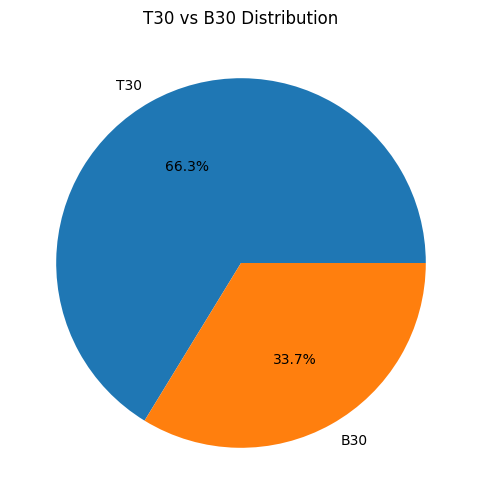

In [13]:
tier = txn["city_tier"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(tier, labels=tier.index, autopct="%1.1f%%")
plt.title("T30 vs B30 Distribution")
plt.savefig("charts/city_tier_distribution.png")
plt.show()

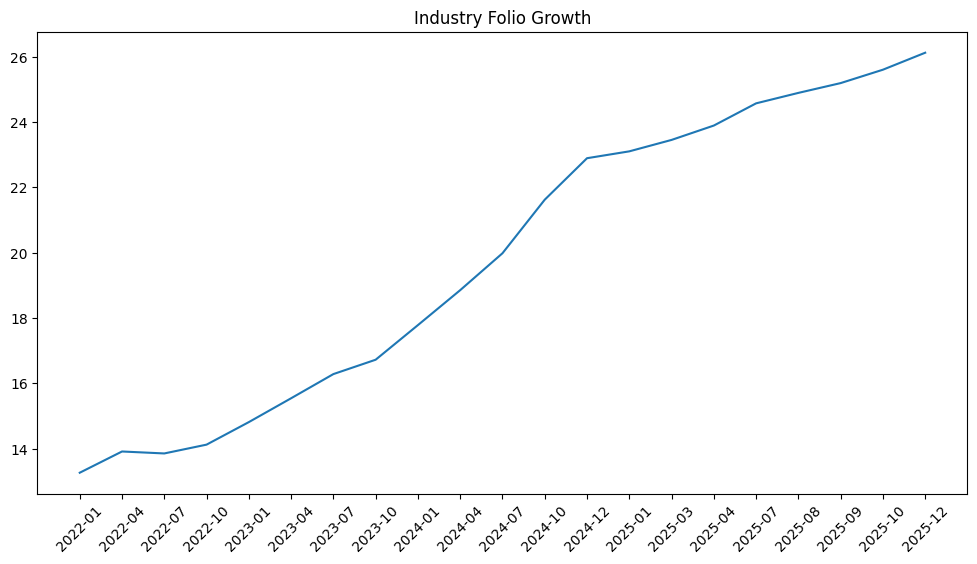

In [14]:
folio = pd.read_csv(
    "data/processed/06_industry_folio_count_cleaned.csv"
)

plt.figure(figsize=(12,6))
plt.plot(folio["month"], folio["total_folios_crore"])

plt.xticks(rotation=45)
plt.title("Industry Folio Growth")

plt.savefig("charts/folio_growth.png")
plt.show()

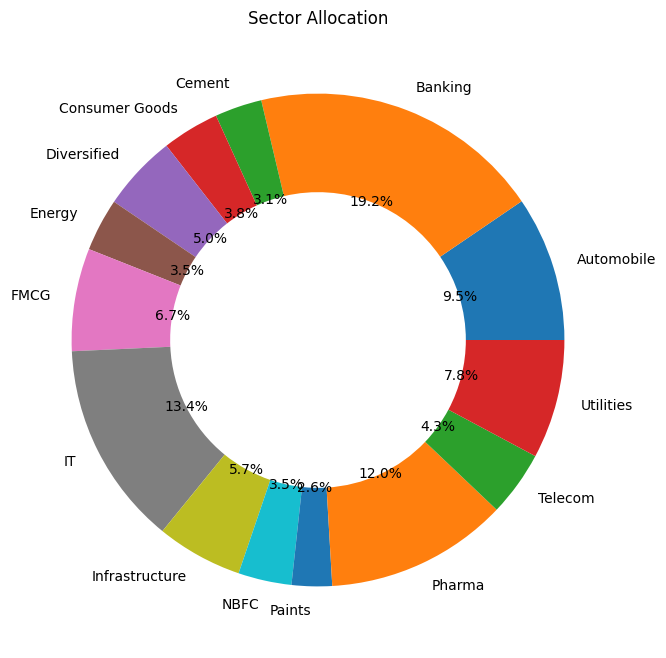

In [15]:
portfolio = pd.read_csv(
    "data/processed/09_portfolio_holdings_cleaned.csv"
)

sector = portfolio.groupby("sector")["weight_pct"].sum()

plt.figure(figsize=(8,8))
plt.pie(
    sector,
    labels=sector.index,
    autopct="%1.1f%%",
    wedgeprops={"width":0.4}
)

plt.title("Sector Allocation")
plt.savefig("charts/sector_allocation.png")
plt.show()

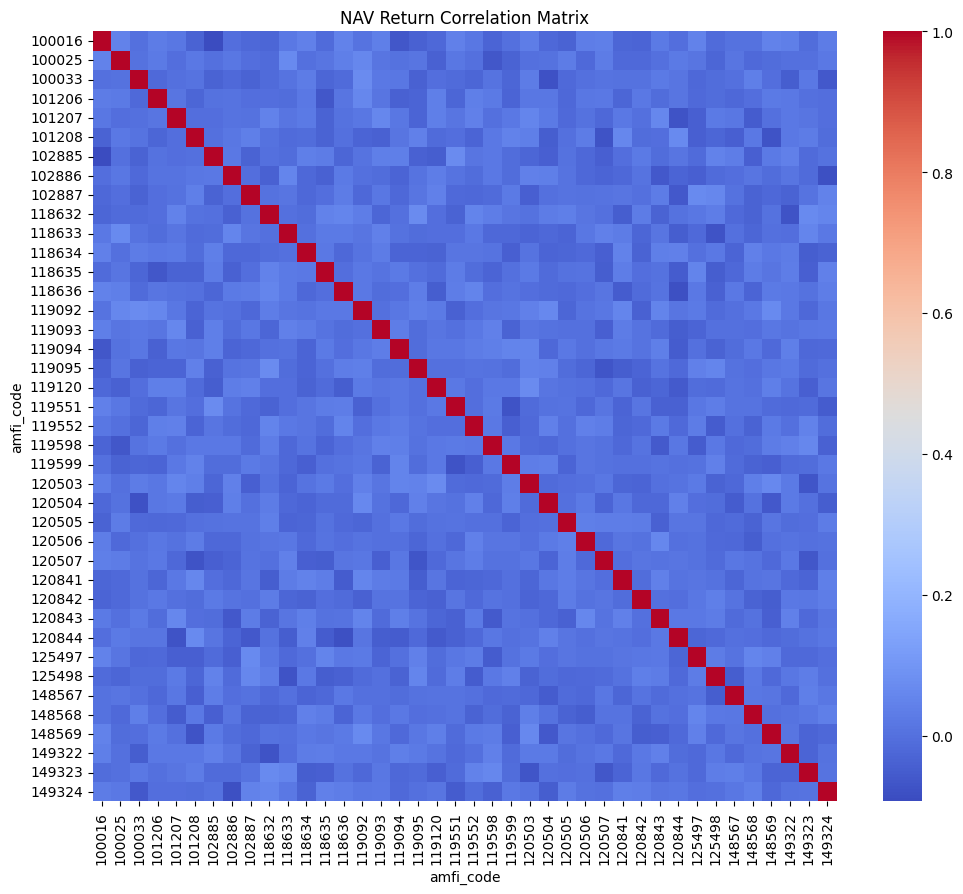

In [16]:
pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")

plt.title("NAV Return Correlation Matrix")
plt.savefig("charts/correlation_matrix.png")
plt.show()

In [17]:
import pandas as pd

nav = pd.read_csv(
    "data/processed/02_nav_history_cleaned.csv"
)

nav["date"] = pd.to_datetime(nav["date"])

print(nav.shape)

(46000, 3)


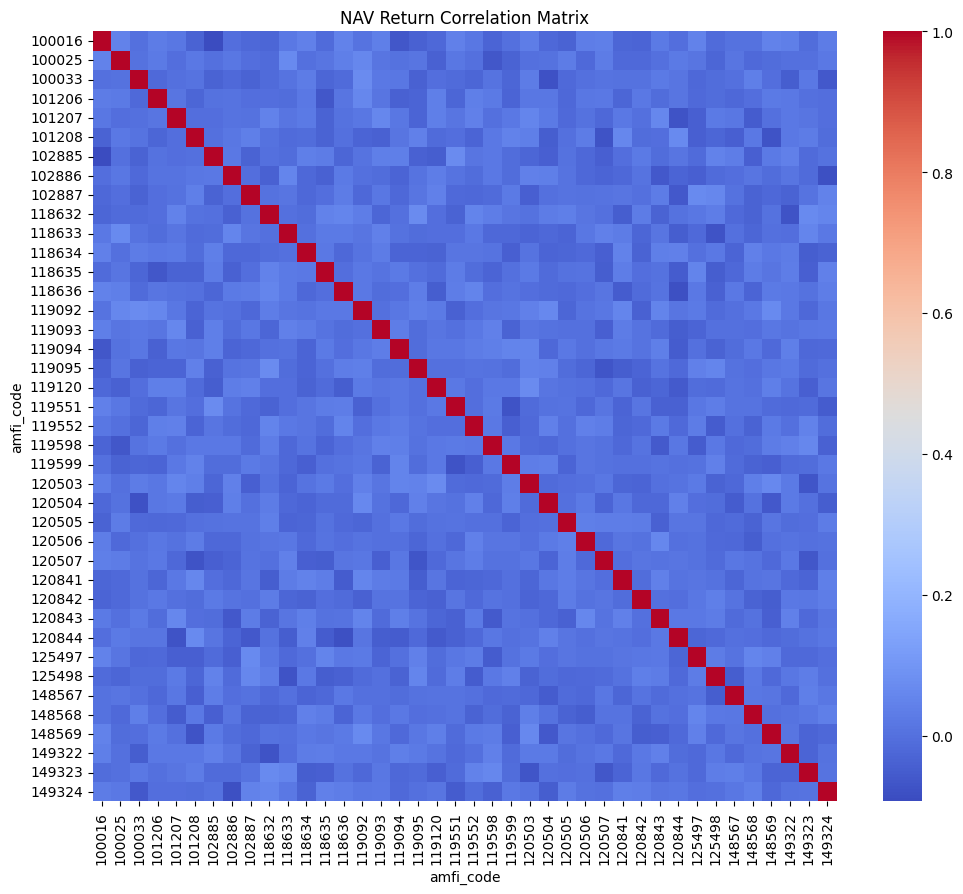

In [18]:
pivot = nav.pivot(
    index="date",
    columns="amfi_code",
    values="nav"
)

returns = pivot.pct_change()

corr = returns.corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap="coolwarm")

plt.title("NAV Return Correlation Matrix")
plt.savefig("charts/correlation_matrix.png")
plt.show()

In [19]:
import pandas as pd

nav = pd.read_csv("data/processed/02_nav_history_cleaned.csv")
nav["date"] = pd.to_datetime(nav["date"])

txn = pd.read_csv("data/processed/08_investor_transactions_cleaned.csv")

sip = pd.read_csv("data/processed/04_monthly_sip_inflows_cleaned.csv")

aum = pd.read_csv("data/processed/03_aum_by_fund_house_cleaned.csv")

category = pd.read_csv("data/processed/05_category_inflows_cleaned.csv")

folio = pd.read_csv("data/processed/06_industry_folio_count_cleaned.csv")

portfolio = pd.read_csv("data/processed/09_portfolio_holdings_cleaned.csv")

print("All datasets loaded successfully!")

All datasets loaded successfully!


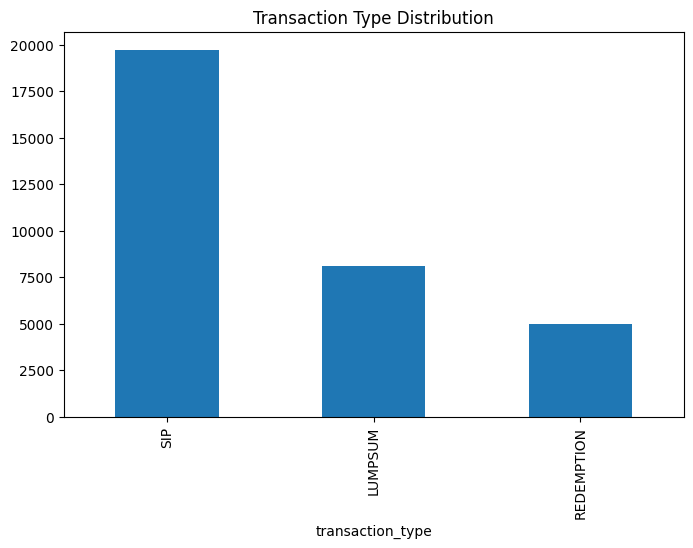

In [20]:
txn["transaction_type"].value_counts().plot(
    kind="bar",
    figsize=(8,5),
    title="Transaction Type Distribution"
)

plt.savefig("charts/transaction_type_distribution.png")
plt.show()

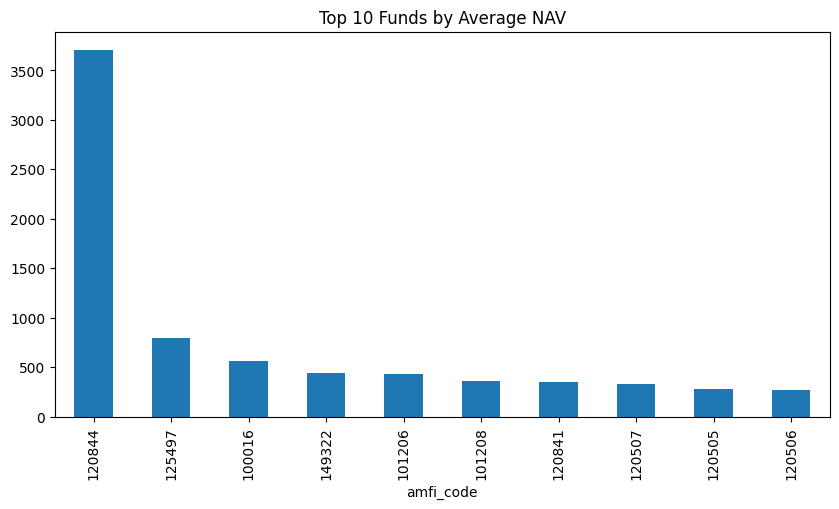

In [22]:
top_nav = nav.groupby("amfi_code")["nav"].mean().sort_values(
    ascending=False
).head(10)

top_nav.plot(kind="bar", figsize=(10,5))

plt.title("Top 10 Funds by Average NAV")
plt.savefig("charts/top10_avg_nav.png")
plt.show()

In [ ]:
1. NAV values showed a generally upward trend across most mutual fund schemes from 2022–2025.

2. SIP inflows increased steadily over the study period, indicating growing retail participation.

3. SBI and other large fund houses dominated industry AUM.

4. Equity-oriented categories attracted higher inflows than most debt categories.

5. Investor participation was concentrated in a few major age groups.

6. Investment amounts varied significantly across age groups.

7. T30 cities contributed a larger share of investments than B30 cities.

8. Folio counts increased consistently, reflecting growth in mutual fund adoption.

9. Portfolio allocations were concentrated in a limited number of sectors.

10. Most mutual fund schemes showed positive return correlations with one another.


In [32]:
print(txn.columns)

Index(['investor_id', 'transaction_date', 'amfi_code', 'transaction_type',
       'amount_inr', 'state', 'city', 'city_tier', 'age_group', 'gender',
       'annual_income_lakh', 'payment_mode', 'kyc_status'],
      dtype='object')


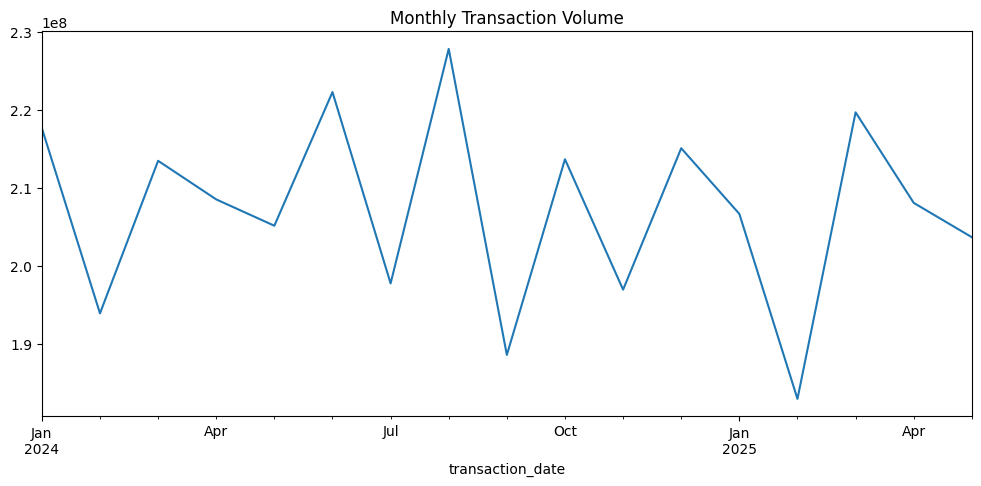

In [33]:
txn["transaction_date"] = pd.to_datetime(txn["transaction_date"])

monthly = txn.groupby(txn["transaction_date"].dt.to_period("M"))["amount_inr"].sum()

monthly.plot(figsize=(12,5))

plt.title("Monthly Transaction Volume")
plt.savefig("charts/monthly_transaction_volume.png")
plt.show()